# 07: CE + Session-Aware Subject Meta-Adaptation (NM)

This notebook implements a two-stage cross-subject recognition protocol:
1) **Stage A**: supervised CE training on train subjects,
2) **Stage B**: session-aware subject adaptation on the target subject.

Practical goal: estimate how much adaptation on part of the target subject sessions
improves performance on the remaining sessions compared to `pure zero-shot` and `pre-adapt proto` modes.


## 1. Experiment Protocol and Math

### 1.1 Data Split (Session-Aware)

For each fold, a `test subject` is selected, and its sessions are split into:
- `adapt` (about 50%),
- `eval` (the remaining sessions).

The same is done for each `val subject` (for Stage A monitoring).

### 1.2 Subject-Level Normalization

For each channel $c$, robust statistics are computed on the subject train part:

$$
\mu_c = \mathrm{median}(x_c), \quad
\sigma_c = 1.4826 \cdot \mathrm{median}(|x_c - \mu_c|)
$$

Window normalization:

$$
\tilde{x}_{t,c} = \frac{\mathrm{clip}(x_{t,c}, -a, a) - \mu_c}{\sigma_c + \varepsilon}
$$

### 1.3 Stage A: Standard CE Training

The model is trained on train subjects with cross-entropy:

$$
\mathcal{L}_{CE} = -\frac{1}{B}\sum_{i=1}^{B}\log p_{\theta}(y_i \mid x_i)
$$

Early stopping criterion: `val_adapt_monitor_f1` (macro-F1 after short meta-adaptation on val subjects).

### 1.4 Target-Subject Meta-Adaptation

For each episode, `n_way`, `k_shot`, `q_query` are sampled and prototypes are built:

$$
\mathbf{p}_c = \frac{1}{|S_c|}\sum_{(x,y)\in S_c} f_{\theta}(x)
$$

Query logits are negative squared distances:

$$
\ell_c(x_q) = -\|f_{\theta}(x_q) - \mathbf{p}_c\|_2^2
$$

Episode loss:

$$
\mathcal{L}_{meta} = \mathrm{CE}(\ell(x_q), y_q)
$$

After a series of episodes, quality is evaluated on `eval`.

### 1.5 Main Metric

Macro-F1 is used:

$$
F1_{macro} = \frac{1}{|\mathcal{C}|}\sum_{c\in\mathcal{C}} F1_c
$$


## 2. Imports


In [12]:
from __future__ import annotations

from pathlib import Path
import sys
import json
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_ROOT = PROJECT_ROOT / 'data'
SRC_DIR = PROJECT_ROOT / 'src'

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import dataset_io as dio
import notebook02_experiment_b_utils as expb

dio = importlib.reload(dio)
expb = importlib.reload(expb)

load_varlen_npz_dataset = dio.load_varlen_npz_dataset

print('PROJECT_ROOT:', PROJECT_ROOT)


PROJECT_ROOT: /home/bobr/Documents/LABMITING/KURSOVAYA_1/code_bobr_678


## 3. Configuration


In [13]:
# Paths
NM_NPZ = DATA_ROOT / 'datasets' / 'nm_digits_varlen_16ch.npz'
MODEL_PY = PROJECT_ROOT / 'models' / 'cnn_transformer_loso_v2.py'
OUT_DIR = PROJECT_ROOT / 'reports' / 'artifacts' / 'notebook02'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Split config
SPLIT_CFG = {
    'seed': 42,
    'n_folds': 10,
    'n_val_subjects': 2,
    'test_subject_exclude_prefixes': [],
    'min_eval_sessions': 2,
}

# Normalization
SUBJECT_NORM_CFG = {
    'clip': 6.0,
    'method': 'robust',
    'eps': 1e-6,
}

# Length cap (for stable memory usage)
LENGTH_CAP_CFG = {
    'policy': 'mean_train',
}

# Stage A: CE-train
STAGEA_CFG = {
    'seed': 42,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'epochs': 70,
    'batch_size': 64,
    'lr': 7e-4,
    'weight_decay': 1e-4,
    'patience': 15,
    'grad_clip': 1.0,
    'monitor': 'val_adapt_monitor_f1',
    'monitor_mode': 'max',
    'monitor_adapt_episodes': 50,
}

# Stage B: meta-adapt
META_ADAPT_CFG = {
    'episodes': 80,
    'lr': 2.5e-4,
    'weight_decay': 1e-4,
    'grad_clip': 1.0,
    'embedding_norm': True,
    'n_way': 5,
    'k_shot': 6,
    'q_query': 6,
    'min_adapt_samples_for_train': 10,
    'min_q_query_for_train': 2,
}

# Architecture
MODEL_CFG = {
    'd_model': 64,
    'stride_cnn': 8,
    'k_cnn': 21,
    'n_heads': 4,
    'ff_dim': 256,
    'num_layers': 2,
    'dropout': 0.2,
}

print('NM_NPZ:', NM_NPZ)
print('MODEL_PY:', MODEL_PY)
print('OUT_DIR:', OUT_DIR)
print('DEVICE:', STAGEA_CFG['device'])


NM_NPZ: /home/bobr/Documents/LABMITING/KURSOVAYA_1/code_bobr_678/data/datasets/nm_digits_varlen_16ch.npz
MODEL_PY: /home/bobr/Documents/LABMITING/KURSOVAYA_1/code_bobr_678/models/cnn_transformer_loso_v2.py
OUT_DIR: /home/bobr/Documents/LABMITING/KURSOVAYA_1/code_bobr_678/reports/artifacts/notebook02
DEVICE: cuda


## 4. Dataset Loading and Session-Aware Fold Construction


In [14]:
expb.set_seed(int(STAGEA_CFG['seed']))

ds = load_varlen_npz_dataset(NM_NPZ)
if 'session' not in ds:
    raise RuntimeError(
        "Dataset has no `session` field. Rebuild the NPZ from notebook 01 while preserving the session field."
    )

folds, subject_session_counts, eligible_eval_subjects = expb.make_session_aware_subject_folds(
    ds['subject'],
    ds['session'],
    n_folds=int(SPLIT_CFG['n_folds']),
    n_val_subjects=int(SPLIT_CFG['n_val_subjects']),
    seed=int(SPLIT_CFG['seed']),
    min_eval_sessions=int(SPLIT_CFG['min_eval_sessions']),
    test_subject_exclude_prefixes=list(SPLIT_CFG['test_subject_exclude_prefixes']),
)

lengths = np.asarray(ds['lengths'])
subjects = np.asarray(ds['subject']).astype(str)

print('samples:', len(ds['target']))
print('subjects:', len(np.unique(subjects)))
print('eligible eval subjects (>=2 sessions):', len(eligible_eval_subjects))
print('classes:', sorted(np.unique(ds['target']).tolist()))
print('channels:', ds['emg_concat'].shape[1])
print('length stats:', {
    'min': int(lengths.min()),
    'median': float(np.median(lengths)),
    'mean': float(lengths.mean()),
    'max': int(lengths.max()),
})

fold_table = []
for f in folds:
    test_subj = str(f.test_subjects[0])
    fold_table.append({
        'fold': f.fold_id,
        'n_train': len(f.train_idx),
        'n_val': len(f.val_idx),
        'n_test': len(f.test_idx),
        'val_subjects': ', '.join(f.val_subjects),
        'test_subject': test_subj,
        'test_subject_sessions': int(subject_session_counts.get(test_subj, 0)),
    })

fold_df_preview = pd.DataFrame(fold_table)
fold_df_preview


samples: 7018
subjects: 91
eligible eval subjects (>=2 sessions): 86
classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
channels: 16
length stats: {'min': 740, 'median': 1411.0, 'mean': 2024.880022798518, 'max': 23360}


,fold,n_train,n_val,n_test,val_subjects,test_subject,test_subject_sessions
0,1,6768,130,120,"sub-027, sub-034",sub-005,12
1,2,6828,100,90,"sub-000, sub-070",sub-040,9
2,3,6779,150,89,"sub-042, sub-056",sub-003,9
3,4,6829,130,59,"sub-000, sub-036",sub-068,6
4,5,6848,130,40,"sub-053, sub-080",sub-074,4
5,6,6788,140,90,"sub-062, sub-085",sub-029,9
6,7,6748,180,90,"sub-025, sub-071",sub-047,9
7,8,6758,210,50,"sub-059, sub-073",sub-042,5
8,9,6809,139,70,"sub-024, sub-068",sub-090,7
9,10,6798,140,80,"sub-058, sub-072",sub-028,8


## 5. Quick EDA Before Training


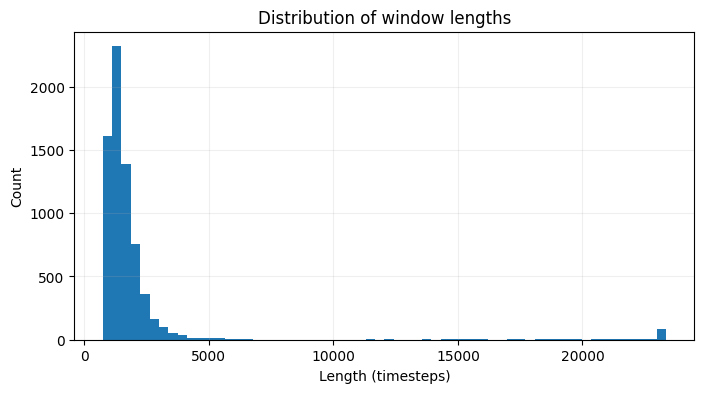

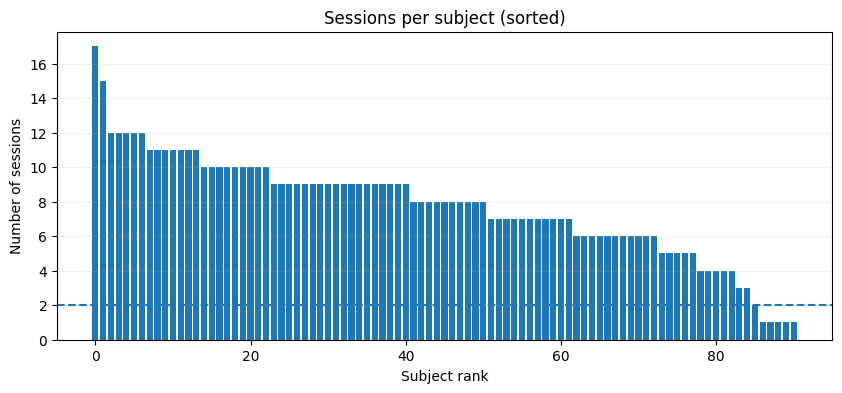

,subject,n_sessions
28,sub-030,17
47,sub-050,15
4,sub-005,12
15,sub-017,12
71,sub-076,12
10,sub-012,12
12,sub-014,12
43,sub-046,11
23,sub-025,11
7,sub-008,11


In [15]:
# Window length distribution
plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=60)
plt.title('Distribution of window lengths')
plt.xlabel('Length (timesteps)')
plt.ylabel('Count')
plt.grid(alpha=0.2)
plt.show()

# Number of sessions per subject
sess_count_df = pd.DataFrame({
    'subject': sorted(subject_session_counts.keys()),
    'n_sessions': [subject_session_counts[s] for s in sorted(subject_session_counts.keys())],
}).sort_values('n_sessions', ascending=False)

plt.figure(figsize=(10, 4))
plt.bar(np.arange(len(sess_count_df)), sess_count_df['n_sessions'].to_numpy())
plt.axhline(SPLIT_CFG['min_eval_sessions'], linestyle='--')
plt.title('Sessions per subject (sorted)')
plt.xlabel('Subject rank')
plt.ylabel('Number of sessions')
plt.grid(axis='y', alpha=0.2)
plt.show()

sess_count_df.head(12)


## 6. Run CE + Session-Aware Subject Meta-Adaptation

The full pipeline below runs:
1. Stage A CE training on train subjects,
2. Stage B adaptation on `adapt` sessions,
3. evaluation in three modes: `pure zero-shot`, `pre-adapt proto`, `adapted`.


In [16]:
ModelClass = expb.load_model_class(MODEL_PY)

fold_metrics_df, history_df, val_detail_df, summary = expb.run_experiment_b(
    ds=ds,
    folds=folds,
    model_class=ModelClass,
    model_cfg=MODEL_CFG,
    split_cfg=SPLIT_CFG,
    subject_norm_cfg=SUBJECT_NORM_CFG,
    stagea_cfg=STAGEA_CFG,
    meta_adapt_cfg=META_ADAPT_CFG,
    length_cap_cfg=LENGTH_CAP_CFG,
    out_dir=OUT_DIR,
    save_checkpoints=False,
)

print(json.dumps(summary, indent=2, ensure_ascii=False))


[fold 1] start | seed=43 train=6768 val=130 test=120
[fold 1] epoch=001/070 train_loss=2.3108 train_acc=0.1200 val0_f1=0.0540 valAmon_f1=0.0962
[fold 1] epoch=002/070 train_loss=2.2693 train_acc=0.1361 val0_f1=0.0537 valAmon_f1=0.1030
[fold 1] epoch=003/070 train_loss=2.2154 train_acc=0.1678 val0_f1=0.0660 valAmon_f1=0.1566
[fold 1] epoch=004/070 train_loss=2.1517 train_acc=0.2057 val0_f1=0.0507 valAmon_f1=0.2165
[fold 1] epoch=005/070 train_loss=2.0558 train_acc=0.2456 val0_f1=0.0715 valAmon_f1=0.2192
[fold 1] epoch=006/070 train_loss=1.9602 train_acc=0.2849 val0_f1=0.0805 valAmon_f1=0.2700
[fold 1] epoch=007/070 train_loss=1.8576 train_acc=0.3332 val0_f1=0.2145 valAmon_f1=0.3323
[fold 1] epoch=008/070 train_loss=1.7711 train_acc=0.3586 val0_f1=0.1942 valAmon_f1=0.4352
[fold 1] epoch=009/070 train_loss=1.6621 train_acc=0.4044 val0_f1=0.1833 valAmon_f1=0.4118
[fold 1] epoch=010/070 train_loss=1.6015 train_acc=0.4307 val0_f1=0.2845 valAmon_f1=0.4314
[fold 1] epoch=011/070 train_loss=1.5

## 7. Protocol Results Analysis


In [17]:
display_cols = [
    'fold', 'test_subject', 'best_epoch_stageA',
    'val_adapt_monitor_f1',
    'test_zero_shot_f1_macro',
    'test_pre_adapt_proto_f1_macro',
    'test_adapt_f1_macro',
    'test_adapt_valid',
    'n_way', 'k_shot', 'q_query',
    'test_subject_n_sessions_total',
    'adapt_applied_test', 'skip_reason_test',
]

fold_metrics_df[display_cols]


,fold,test_subject,best_epoch_stageA,val_adapt_monitor_f1,test_zero_shot_f1_macro,test_pre_adapt_proto_f1_macro,test_adapt_f1_macro,test_adapt_valid,n_way,k_shot,q_query,test_subject_n_sessions_total,adapt_applied_test,skip_reason_test
0,1,sub-005,47,0.740357,0.221678,0.552112,0.630048,1,5,1,5,12,1,
1,2,sub-040,35,0.862857,0.705000,0.743529,0.694840,1,5,1,3,9,1,
2,3,sub-003,24,0.580040,0.669957,0.807814,0.776717,1,5,1,3,9,1,
3,4,sub-068,33,0.544535,0.406587,0.411429,0.419048,1,5,1,2,6,1,
4,5,sub-074,20,0.610699,0.343333,0.281905,0.281905,0,5,1,1,4,0,q_query<2
5,6,sub-029,54,0.572121,0.507718,0.710139,0.740880,1,5,1,3,9,1,
6,7,sub-047,59,0.753178,0.516587,0.603342,0.615733,1,5,1,3,9,1,
7,8,sub-042,29,0.674003,0.826190,0.705000,0.705000,0,5,1,1,5,0,q_query<2
8,9,sub-090,55,0.622381,0.400238,0.488333,0.581429,1,5,1,3,7,1,
9,10,sub-028,32,0.691991,0.520657,0.475397,0.487410,1,5,1,3,8,1,


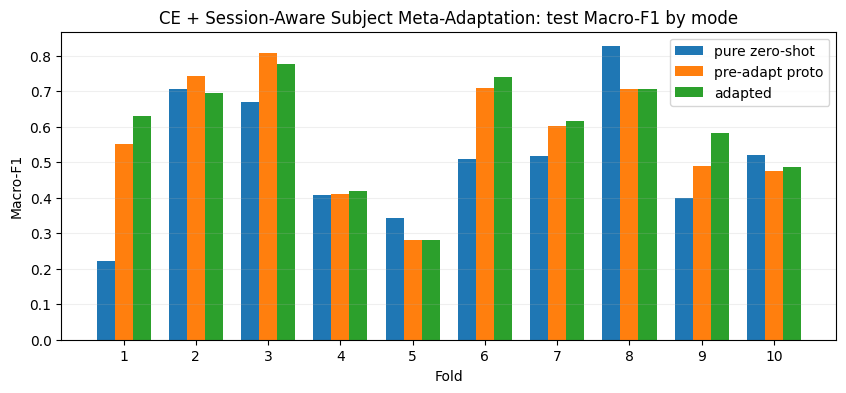

In [18]:
# Test-mode comparison across folds
plot_df = fold_metrics_df[['fold', 'test_zero_shot_f1_macro', 'test_pre_adapt_proto_f1_macro', 'test_adapt_f1_macro']].copy()
plot_df = plot_df.sort_values('fold')

x = np.arange(len(plot_df))
w = 0.25

plt.figure(figsize=(10, 4))
plt.bar(x - w, plot_df['test_zero_shot_f1_macro'], width=w, label='pure zero-shot')
plt.bar(x,     plot_df['test_pre_adapt_proto_f1_macro'], width=w, label='pre-adapt proto')
plt.bar(x + w, plot_df['test_adapt_f1_macro'], width=w, label='adapted')

plt.xticks(x, plot_df['fold'].astype(int).tolist())
plt.xlabel('Fold')
plt.ylabel('Macro-F1')
plt.title('CE + Session-Aware Subject Meta-Adaptation: test Macro-F1 by mode')
plt.grid(axis='y', alpha=0.2)
plt.legend()
plt.show()


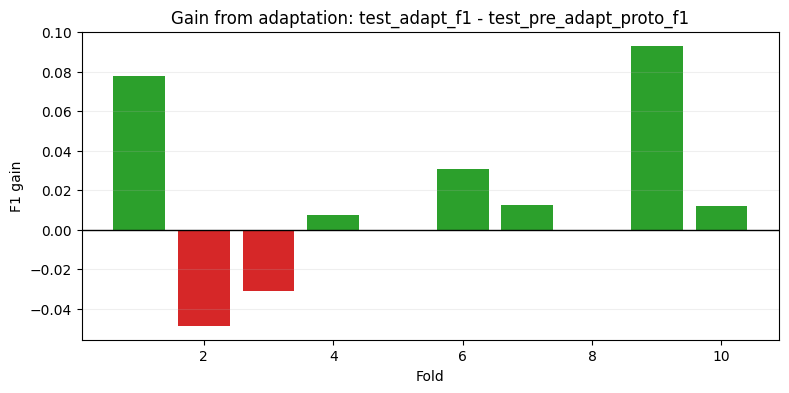

,fold,test_subject,gain_test_adapt_vs_pre,skip_reason_test
0,1,sub-005,0.077936,
1,2,sub-040,-0.048689,
2,3,sub-003,-0.031097,
3,4,sub-068,0.007619,
4,5,sub-074,0.000000,q_query<2
5,6,sub-029,0.030741,
6,7,sub-047,0.012390,
7,8,sub-042,0.000000,q_query<2
8,9,sub-090,0.093095,
9,10,sub-028,0.012013,


In [19]:
# Adaptation gain on test (adapted - pre-adapt)
fold_metrics_df = fold_metrics_df.copy()
fold_metrics_df['gain_test_adapt_vs_pre'] = (
    fold_metrics_df['test_adapt_f1_macro'] - fold_metrics_df['test_pre_adapt_proto_f1_macro']
)

plt.figure(figsize=(9, 4))
colors = ['#2ca02c' if v >= 0 else '#d62728' for v in fold_metrics_df['gain_test_adapt_vs_pre']]
plt.bar(fold_metrics_df['fold'].astype(int), fold_metrics_df['gain_test_adapt_vs_pre'], color=colors)
plt.axhline(0.0, color='black', linewidth=1)
plt.xlabel('Fold')
plt.ylabel('F1 gain')
plt.title('Gain from adaptation: test_adapt_f1 - test_pre_adapt_proto_f1')
plt.grid(axis='y', alpha=0.2)
plt.show()

fold_metrics_df[['fold', 'test_subject', 'gain_test_adapt_vs_pre', 'skip_reason_test']]


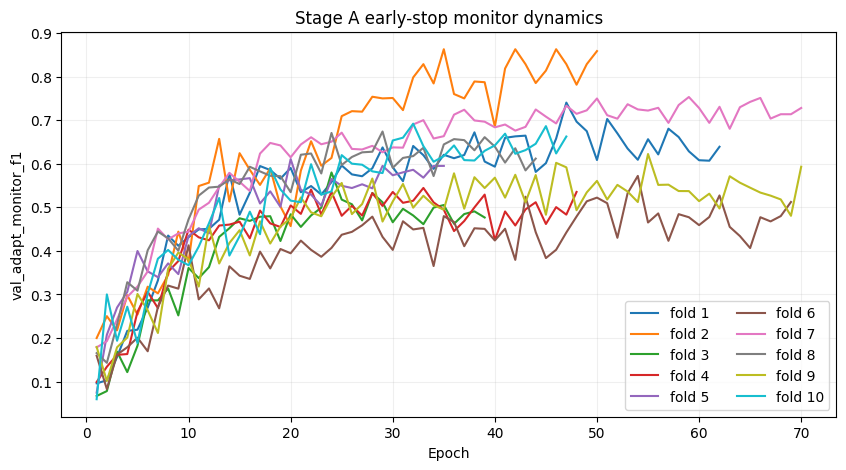

In [20]:
# Stage A curves: monitor F1 by epoch
plt.figure(figsize=(10, 5))
for fold_id, part in history_df.groupby('fold'):
    p = part.sort_values('epoch')
    plt.plot(p['epoch'], p['val_adapt_monitor_f1'], label=f'fold {int(fold_id)}')

plt.xlabel('Epoch')
plt.ylabel('val_adapt_monitor_f1')
plt.title('Stage A early-stop monitor dynamics')
plt.grid(alpha=0.2)
plt.legend(ncol=2)
plt.show()


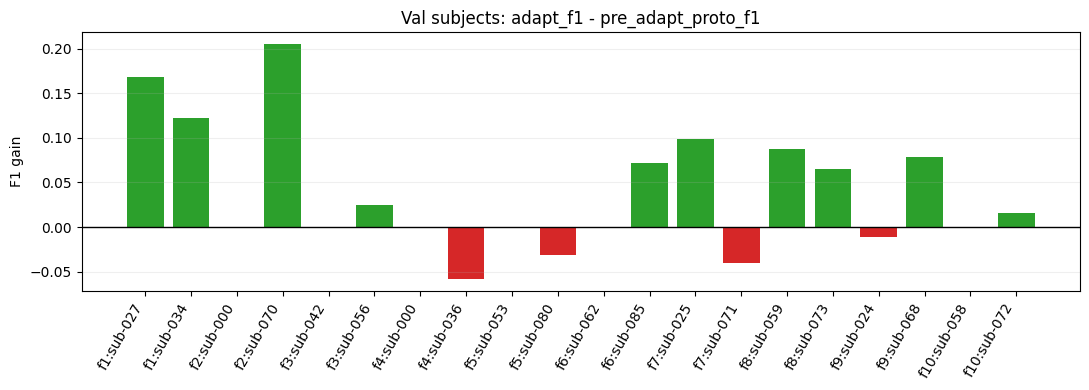

,fold,val_subject,pre_adapt_proto_f1_macro,adapt_f1_macro,gain_val_adapt_vs_pre,skip_reason
0,1,sub-027,0.655238,0.823095,0.167857,
1,1,sub-034,0.413810,0.536667,0.122857,
2,2,sub-000,0.326667,0.326667,0.000000,q_query<2
3,2,sub-070,0.579048,0.784286,0.205238,
4,3,sub-042,0.481905,0.481905,0.000000,q_query<2
5,3,sub-056,0.490716,0.515079,0.024363,
6,4,sub-000,0.230000,0.230000,0.000000,q_query<2
7,4,sub-036,0.552619,0.493838,-0.058781,
8,5,sub-053,0.040000,0.040000,0.000000,n_way<2
9,5,sub-080,0.554163,0.522222,-0.031941,


In [21]:
# Per-validation-subject details
val_detail_df = val_detail_df.copy()
val_detail_df['gain_val_adapt_vs_pre'] = val_detail_df['adapt_f1_macro'] - val_detail_df['pre_adapt_proto_f1_macro']

plt.figure(figsize=(11, 4))
x = np.arange(len(val_detail_df))
colors = ['#2ca02c' if v >= 0 else '#d62728' for v in val_detail_df['gain_val_adapt_vs_pre']]
plt.bar(x, val_detail_df['gain_val_adapt_vs_pre'], color=colors)
plt.axhline(0.0, color='black', linewidth=1)
plt.xticks(x, [f"f{int(r.fold)}:{r.val_subject}" for r in val_detail_df.itertuples()], rotation=60, ha='right')
plt.ylabel('F1 gain')
plt.title('Val subjects: adapt_f1 - pre_adapt_proto_f1')
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

val_detail_df[['fold', 'val_subject', 'pre_adapt_proto_f1_macro', 'adapt_f1_macro', 'gain_val_adapt_vs_pre', 'skip_reason']]


## Data Split Protocol

**Protocol ID:** `notebook02_split_protocol_v2`  
**Experiment:** NM session-aware subject adaptation (`CE -> meta-adapt`)

- **Unit of split:**
  - Stage A outer split: subject-level folds.
  - Stage B inner split: session-level `adapt/eval` inside each validation/test subject.
- **Stratification rule:** no class stratification at outer split; inner split preserves session boundaries and randomly assigns sessions to `adapt/eval` with ~50/50 ratio.
- **Fold config:** `n_folds=5`, `n_val_subjects=2`, `min_eval_sessions=2`.
- **Seed policy:**
  - subject folds from `SPLIT_CFG['seed']`;
  - per-fold operational seed `STAGEA_CFG['seed'] + fold_id`;
  - session split seeds follow code path (`+100+i` for val subjects, `+777` for test subject).
- **Constraints/minimums:** validation/test subject candidates must have at least 2 sessions; each required adapt/eval partition must be non-empty.
- **Stage A usage:** train on fold `train_subjects`; monitor with `val_adapt_monitor_f1` using validation subjects (`adapt` as support, `eval` as query).
- **Stage B usage:** adapt on test-subject `adapt` sessions; final test on test-subject `eval` sessions.


In [ ]:
# Auditable split protocol block
SPLIT_PROTOCOL_VERSION = 'notebook02_split_protocol_v2'

from pathlib import Path
import json
import numpy as np
import pandas as pd

AUDIT_OUT_DIR = PROJECT_ROOT / 'reports' / 'artifacts' / 'notebook02'
AUDIT_OUT_DIR.mkdir(parents=True, exist_ok=True)

subjects_full = np.asarray(ds['subject']).astype(str)
sessions_full = np.asarray(ds['session']).astype(str)

sess_counts = expb.get_subject_session_counts(subjects_full, sessions_full)
eligible_eval_subjects = sorted([s for s, n_sess in sess_counts.items() if int(n_sess) >= int(SPLIT_CFG['min_eval_sessions'])])

fold_rows = []
session_rows = []

for fold in folds:
    fold_id = int(fold.fold_id)
    fold_seed = int(STAGEA_CFG['seed']) + fold_id

    train_subjects = sorted([str(s) for s in fold.train_subjects])
    val_subjects = sorted([str(s) for s in fold.val_subjects])
    test_subject = str(fold.test_subjects[0])

    # Outer split assertions.
    assert test_subject not in train_subjects, f'test subject present in train for fold {fold_id}'
    assert test_subject not in val_subjects, f'test subject present in val for fold {fold_id}'
    assert set(train_subjects).isdisjoint(set(val_subjects)), f'train/val subject overlap in fold {fold_id}'
    assert int(sess_counts.get(test_subject, 0)) >= int(SPLIT_CFG['min_eval_sessions']), (
        f'test subject {test_subject} violates min_eval_sessions'
    )

    # Inner split assertions for test subject.
    test_idx = np.where(subjects_full == test_subject)[0].astype(np.int64)
    t_adapt_idx, t_eval_idx, t_info = expb.split_subject_adapt_eval_by_sessions(
        sessions_full,
        test_idx,
        seed=fold_seed + 777,
        ratio=0.5,
    )
    assert len(t_adapt_idx) > 0 and len(t_eval_idx) > 0, f'empty test adapt/eval in fold {fold_id}'

    fold_rows.append({
        'fold': fold_id,
        'seed': fold_seed,
        'n_train': int(len(fold.train_idx)),
        'n_validation': int(len(fold.val_idx)),
        'n_test': int(len(fold.test_idx)),
        'train_subject_count': int(len(train_subjects)),
        'validation_subject_count': int(len(val_subjects)),
        'test_subject': test_subject,
        'test_subject_sessions_total': int(t_info['n_sessions_total']),
        'test_subject_sessions_adapt': int(t_info['n_sessions_adapt']),
        'test_subject_sessions_eval': int(t_info['n_sessions_eval']),
        'test_subject_trials_adapt': int(len(t_adapt_idx)),
        'test_subject_trials_eval': int(len(t_eval_idx)),
    })

    session_rows.append({
        'fold': fold_id,
        'subject_role': 'test',
        'subject': test_subject,
        'n_sessions_total': int(t_info['n_sessions_total']),
        'n_sessions_adapt': int(t_info['n_sessions_adapt']),
        'n_sessions_eval': int(t_info['n_sessions_eval']),
        'adapt_sessions': ';'.join(t_info['adapt_sessions']),
        'eval_sessions': ';'.join(t_info['eval_sessions']),
    })

    for i, vsub in enumerate(val_subjects):
        v_idx = np.where(subjects_full == vsub)[0].astype(np.int64)
        v_adapt_idx, v_eval_idx, v_info = expb.split_subject_adapt_eval_by_sessions(
            sessions_full,
            v_idx,
            seed=fold_seed + 100 + i,
            ratio=0.5,
        )
        assert len(v_adapt_idx) > 0 and len(v_eval_idx) > 0, f'empty val adapt/eval for {vsub} in fold {fold_id}'
        session_rows.append({
            'fold': fold_id,
            'subject_role': 'validation',
            'subject': vsub,
            'n_sessions_total': int(v_info['n_sessions_total']),
            'n_sessions_adapt': int(v_info['n_sessions_adapt']),
            'n_sessions_eval': int(v_info['n_sessions_eval']),
            'adapt_sessions': ';'.join(v_info['adapt_sessions']),
            'eval_sessions': ';'.join(v_info['eval_sessions']),
        })

split_summary_df = pd.DataFrame(fold_rows).sort_values('fold').reset_index(drop=True)
session_split_df = pd.DataFrame(session_rows).sort_values(['fold', 'subject_role', 'subject']).reset_index(drop=True)

protocol_payload = {
    'protocol_id': SPLIT_PROTOCOL_VERSION,
    'experiment': 'notebook02_nm_session_aware_subject_adaptation',
    'outer_split': {
        'unit': 'subject',
        'n_folds': int(SPLIT_CFG['n_folds']),
        'n_validation_subjects_per_fold': int(SPLIT_CFG['n_val_subjects']),
        'min_eval_sessions': int(SPLIT_CFG['min_eval_sessions']),
        'test_subject_exclude_prefixes': list(SPLIT_CFG['test_subject_exclude_prefixes']),
        'seed': int(SPLIT_CFG['seed'])
    },
    'inner_split': {
        'unit': 'session',
        'ratio_adapt_eval': 'approximately 50/50 by session count',
        'preserve_session_boundaries': True,
        'val_seed_rule': 'fold_seed + 100 + i',
        'test_seed_rule': 'fold_seed + 777'
    },
    'eligible_eval_subjects_count': int(len(eligible_eval_subjects)),
    'total_subjects_count': int(len(np.unique(subjects_full))),
    'stage_usage': {
        'stageA': {
            'train': 'fold.train_subjects',
            'validation_monitor': 'fold.validation_subjects adapt/eval via val_adapt_monitor_f1'
        },
        'stageB': {
            'adapt': 'test_subject adapt sessions',
            'final_test': 'test_subject eval sessions'
        }
    },
    'constraints': {
        'non_empty_required_partitions': True,
        'subject_overlap_forbidden': True,
        'min_eval_sessions_enforced': True
    }
}

split_summary_csv = AUDIT_OUT_DIR / 'split_summary.csv'
session_split_csv = AUDIT_OUT_DIR / 'split_session_breakdown.csv'
protocol_json = AUDIT_OUT_DIR / 'split_protocol.json'

split_summary_df.to_csv(split_summary_csv, index=False)
session_split_df.to_csv(session_split_csv, index=False)
protocol_json.write_text(json.dumps(protocol_payload, indent=2, ensure_ascii=False), encoding='utf-8')

print('Saved:', split_summary_csv)
print('Saved:', session_split_csv)
print('Saved:', protocol_json)

display(split_summary_df)
display(session_split_df.head(30))


Saved: /home/bobr/Documents/LABMITING/KURSOVAYA_1/code_bobr_678/reports/artifacts/notebook02/split_summary.csv
Saved: /home/bobr/Documents/LABMITING/KURSOVAYA_1/code_bobr_678/reports/artifacts/notebook02/split_session_breakdown.csv
Saved: /home/bobr/Documents/LABMITING/KURSOVAYA_1/code_bobr_678/reports/artifacts/notebook02/split_protocol.json


,fold,seed,n_train,n_validation,n_test,train_subject_count,validation_subject_count,test_subject,test_subject_sessions_total,test_subject_sessions_adapt,test_subject_sessions_eval,test_subject_trials_adapt,test_subject_trials_eval
0,1,43,6768,130,120,88,2,sub-005,12,6,6,60,60
1,2,44,6828,100,90,88,2,sub-040,9,4,5,40,50
2,3,45,6779,150,89,88,2,sub-003,9,4,5,40,49
3,4,46,6829,130,59,88,2,sub-068,6,3,3,30,29
4,5,47,6848,130,40,88,2,sub-074,4,2,2,20,20
5,6,48,6788,140,90,88,2,sub-029,9,4,5,40,50
6,7,49,6748,180,90,88,2,sub-047,9,4,5,40,50
7,8,50,6758,210,50,88,2,sub-042,5,2,3,20,30
8,9,51,6809,139,70,88,2,sub-090,7,4,3,40,30
9,10,52,6798,140,80,88,2,sub-028,8,4,4,40,40


,fold,subject_role,subject,n_sessions_total,n_sessions_adapt,n_sessions_eval,adapt_sessions,eval_sessions
0,1,test,sub-005,12,6,6,ses-000;ses-001;ses-004;ses-005;ses-006;ses-011,ses-002;ses-003;ses-007;ses-008;ses-009;ses-010
1,1,validation,sub-027,7,4,3,ses-002;ses-004;ses-005;ses-006,ses-000;ses-001;ses-003
2,1,validation,sub-034,6,3,3,ses-001;ses-002;ses-003,ses-000;ses-004;ses-005
3,2,test,sub-040,9,4,5,ses-000;ses-002;ses-006;ses-007,ses-001;ses-003;ses-004;ses-005;ses-008
4,2,validation,sub-000,4,2,2,ses-001;ses-002,ses-000;ses-003
5,2,validation,sub-070,6,3,3,ses-002;ses-003;ses-005,ses-000;ses-001;ses-004
6,3,test,sub-003,9,4,5,ses-003;ses-006;ses-007;ses-008,ses-000;ses-001;ses-002;ses-004;ses-005
7,3,validation,sub-042,5,2,3,ses-000;ses-002,ses-001;ses-003;ses-004
8,3,validation,sub-056,10,5,5,ses-001;ses-003;ses-004;ses-007;ses-008,ses-000;ses-002;ses-005;ses-006;ses-009
9,4,test,sub-068,6,3,3,ses-001;ses-002;ses-004,ses-000;ses-003;ses-005
